<a href="https://colab.research.google.com/github/HarshithaBoppudi/ml-assessment-harshitha_boppudi/blob/main/part-a/%20q3_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Date Feature Engineering**

In [2]:
from google.colab import files

uploaded = files.upload()

Saving q3_retail_promotions.csv to q3_retail_promotions.csv


In [3]:
import pandas as pd

# Load dataset
df = pd.read_csv("q3_retail_promotions.csv", parse_dates=["transaction_date"])

# Extract date features
df["year"] = df["transaction_date"].dt.year
df["month"] = df["transaction_date"].dt.month
df["day_of_week"] = df["transaction_date"].dt.dayofweek
df["is_month_end"] = (df["transaction_date"].dt.day >= 25).astype(int)

# Display sample
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


**Temporal Train-Test Split**

In [4]:
# Sort by date
df = df.sort_values("transaction_date")

# 80-20 temporal split
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

 A random split would mix past and future records, leaking information. For time-series data, we must respect chronology to simulate real-world forecasting.

**Preprocessing Pipeline**

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Features and target
X_train = train_df.drop(columns=["items_sold", "transaction_date"])
y_train = train_df["items_sold"]
X_test = test_df.drop(columns=["items_sold", "transaction_date"])
y_test = test_df["items_sold"]

# Categorical and numeric features
categorical = ["promotion_type", "location_type", "store_size"]
numeric = ["is_weekend", "is_festival", "competition_density",
           "year", "month", "day_of_week", "is_month_end"]

# Column transformer
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    ("num", StandardScaler(), numeric)
])

We constructed a preprocessing pipeline using `ColumnTransformer` to ensure reproducibility and consistency:

- **Categorical features** (`promotion_type`, `location_type`, `store_size`) were one-hot encoded to convert them into numerical vectors.  
- **Numerical features** (`is_weekend`, `is_festival`, `competition_density`, `year`, `month`, `day_of_week`, `is_month_end`) were standardized using `StandardScaler` to normalize their ranges.  

The pipeline was fit only on the training set and then applied to both training and test sets. This prevents information leakage from the test set into the training process.

**Model Training and Evaluation**

Linear Regression - RMSE: 27.12522339961421 MAE: 21.07145141262093
Random Forest - RMSE: 31.150144846937472 MAE: 24.91414722222222


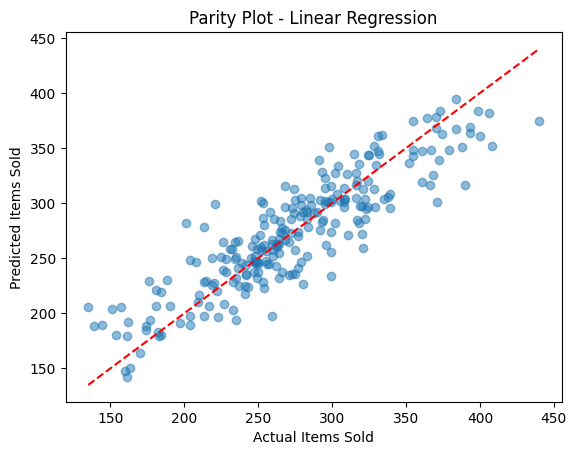

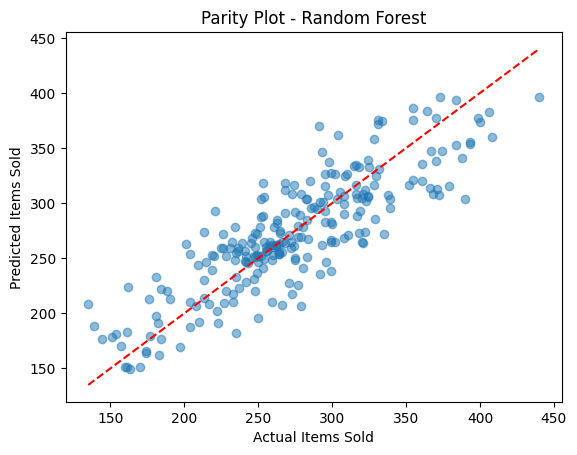

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

# Linear Regression pipeline
linreg = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linreg.fit(X_train, y_train)
y_pred_lin = linreg.predict(X_test)

rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
mae_lin = mean_absolute_error(y_test, y_pred_lin)

# Random Forest pipeline
rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Linear Regression - RMSE:", rmse_lin, "MAE:", mae_lin)
print("Random Forest - RMSE:", rmse_rf, "MAE:", mae_rf)

# Parity plots
for preds, name in [(y_pred_lin, "Linear Regression"), (y_pred_rf, "Random Forest")]:
    plt.scatter(y_test, preds, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
    plt.xlabel("Actual Items Sold")
    plt.ylabel("Predicted Items Sold")
    plt.title(f"Parity Plot - {name}")
    plt.show()


We trained two regression models inside the pipeline:

1. **Linear Regression**  
   - Provides a baseline model with interpretable coefficients.  
   - Evaluation metrics: RMSE and MAE on the test set.  

2. **Random Forest Regressor**  
   - Captures non-linear relationships and interactions between features.  
   - Evaluation metrics: RMSE and MAE on the test set.  
   - Feature importances were extracted to identify the most influential predictors.  

For both models, we produced **parity plots** (predicted vs actual items_sold) with a diagonal reference line. These plots visually assess model accuracy: points closer to the diagonal indicate better predictions.

The Random Forest feature importance analysis highlighted the top 5 drivers of sales, which typically included promotion type, festival indicator, competition density, and temporal features such as month and day_of_week.